# 01a · EDA: what is in the capture

**Question.** What traffic does each capture day contain, which services does it use, and how
do attacks differ from benign traffic before looking at any flow statistic?

Data: the CIC-IDS2017 evaluation copy (`00_data_and_cleaning`), which keeps repeated flows and
conflicting labels as the raw capture has them.

In [1]:
import sys, warnings
sys.path.insert(0, "..")  # make src/ importable from notebooks/
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from sklearn.metrics import roc_auc_score
from src.evaluation.folds import day_key
from src.models.cross_dataset import FAMILY
from src.reporting.plots import style, INK, MUTED
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

df = pd.read_parquet("../data/processed/cicids2017_eval.parquet")
features = df.select_dtypes(include=[np.number]).columns.tolist()
df["day"] = df["Meta_source"].map(lambda s: day_key(s, "2017"))
df["family"] = df["Label"].map(FAMILY)
DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
ATTACK_FAMILIES = ["Brute force (FTP/SSH)", "DoS", "Heartbleed", "Web attack", "Infiltration", "Bot", "PortScan", "DDoS"]
BLUES = LinearSegmentedColormap.from_list("blues", ["#f2f6fc", "#9ec5f4", "#3987e5", "#1c5cab", "#0d366b"])
BENIGN_C, ATTACK_C = "#2a78d6", "#eb6834"
print(f"CIC-IDS2017 evaluation copy: {len(df):,} flows, {len(features)} numeric features")

attacks = df[df["Label"] != "BENIGN"]
days_per_family = attacks.groupby("family")["day"].nunique()
tcp = df.groupby("family")["Has_Init_Win_fwd"].mean()
print(f"Finding: all {len(days_per_family)} attack families occur on a single capture day, so a held-out day is a "
      f"held-out attack type. Every attack family completes a TCP handshake ({tcp.drop('Benign').min():.0%} of "
      f"flows show a TCP window) against {tcp['Benign']:.0%} of benign flows, and most attack families use one "
      f"destination port. Benign traffic's service mix is nearly identical across the five days.")

CIC-IDS2017 evaluation copy: 2,827,726 flows, 71 numeric features


Finding: all 8 attack families occur on a single capture day, so a held-out day is a held-out attack type. Every attack family completes a TCP handshake (100% of flows show a TCP window) against 56% of benign flows, and most attack families use one destination port. Benign traffic's service mix is nearly identical across the five days.


## Which attacks happen on which day

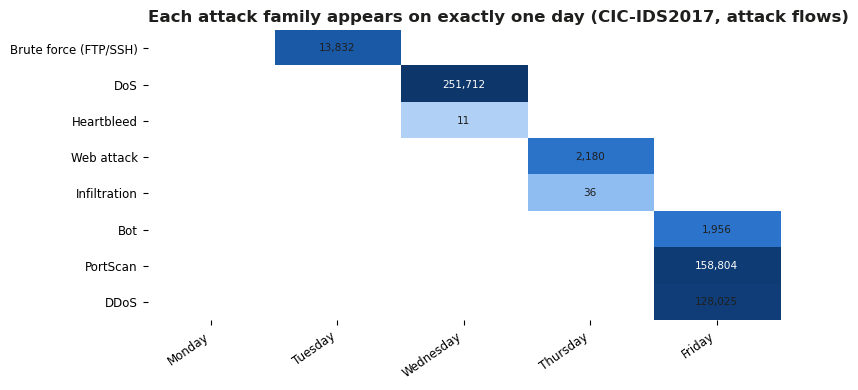

In [2]:
counts = df[df["Label"] != "BENIGN"].groupby(["family", "day"]).size().unstack(fill_value=0).reindex(columns=DAYS, fill_value=0)
counts = counts.loc[ATTACK_FAMILIES]
fig, ax = plt.subplots(figsize=(8, 4))
table = counts.replace(0, np.nan)
ax.imshow(table.values, cmap=BLUES, aspect="auto", norm=LogNorm(vmin=1, vmax=counts.values.max()))
for (i, j), v in np.ndenumerate(table.values):
    if np.isfinite(v) and v != 0:
        ax.text(j, i, f"{int(v):,}", ha="center", va="center", fontsize=7.5,
                color="white" if v > table.values[np.isfinite(table.values)].max() * 0.55 else INK)
ax.set_xticks(range(table.shape[1])); ax.set_xticklabels(table.columns, rotation=35, ha="right", fontsize=8.5)
ax.set_yticks(range(table.shape[0])); ax.set_yticklabels(table.index, fontsize=8.5)
ax.set_title('Each attack family appears on exactly one day (CIC-IDS2017, attack flows)', loc="left", fontweight="bold", color=INK)
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout(); plt.show()

In [3]:
per_day = df.groupby("day").agg(flows=("Label", "size"), attack_share=("Label", lambda s: (s != "BENIGN").mean())).reindex(DAYS)
per_day["attack_share"] = per_day["attack_share"].round(4)
per_day

,flows,attack_share
day,,
Monday,529443,0.0000
Tuesday,445617,0.0310
Wednesday,691384,0.3641
Thursday,458611,0.0048
Friday,702671,0.4110


## Services and protocol

The 2017 CSVs have no protocol column. Two proxies stand in for it: the destination port (the
service a flow talks to) and whether a TCP window was observed (`Has_Init_Win_fwd`), which is
true for TCP flows that completed a handshake and false for UDP, ICMP and handshake-less flows.

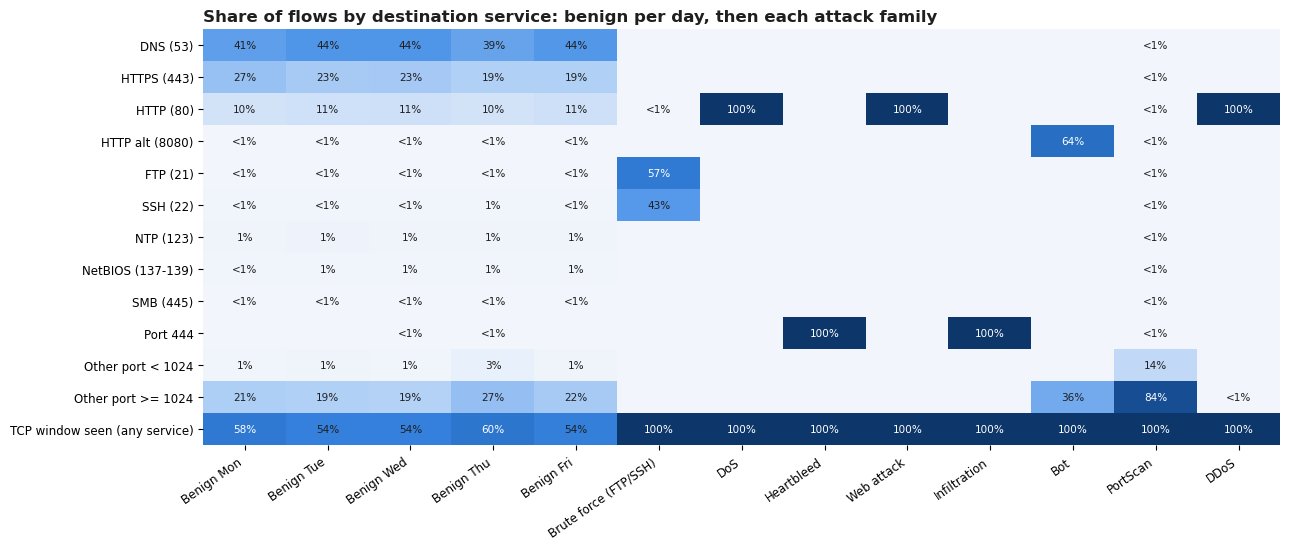

In [4]:
SERVICES = {53: "DNS (53)", 443: "HTTPS (443)", 80: "HTTP (80)", 8080: "HTTP alt (8080)", 21: "FTP (21)",
            22: "SSH (22)", 123: "NTP (123)", 137: "NetBIOS (137-139)", 138: "NetBIOS (137-139)",
            139: "NetBIOS (137-139)", 445: "SMB (445)", 444: "Port 444"}
def service(port):
    return SERVICES.get(port, "Other port < 1024" if port < 1024 else "Other port >= 1024")
df["service"] = df["Destination Port"].map(service)
columns = {f"Benign {d[:3]}": (df["Label"] == "BENIGN") & (df["day"] == d) for d in DAYS}
columns.update({f: df["family"] == f for f in ATTACK_FAMILIES})
order = ["DNS (53)", "HTTPS (443)", "HTTP (80)", "HTTP alt (8080)", "FTP (21)", "SSH (22)", "NTP (123)",
         "NetBIOS (137-139)", "SMB (445)", "Port 444", "Other port < 1024", "Other port >= 1024"]
service_mix = pd.DataFrame({c: df.loc[m, "service"].value_counts(normalize=True) for c, m in columns.items()}).reindex(order).fillna(0)
service_mix.loc["TCP window seen (any service)"] = [df.loc[m, "Has_Init_Win_fwd"].mean() for m in columns.values()]
fig, ax = plt.subplots(figsize=(13, 5.6))
table = service_mix
ax.imshow(table.values, cmap=BLUES, aspect="auto")
for (i, j), v in np.ndenumerate(table.values):
    if np.isfinite(v) and v != 0:
        ax.text(j, i, f"{v:.0%}" if v >= 0.005 else "<1%", ha="center", va="center", fontsize=7.5,
                color="white" if v > table.values[np.isfinite(table.values)].max() * 0.55 else INK)
ax.set_xticks(range(table.shape[1])); ax.set_xticklabels(table.columns, rotation=35, ha="right", fontsize=8.5)
ax.set_yticks(range(table.shape[0])); ax.set_yticklabels(table.index, fontsize=8.5)
ax.set_title('Share of flows by destination service: benign per day, then each attack family', loc="left", fontweight="bold", color=INK)
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout(); plt.show()

## What this shows

- **Day and attack are the same thing in 2017.** Each family sits on one day and Monday has none,
  so any split by day is also a split by attack type (`03_forward_2017`).
- **Benign traffic is stable across days.** DNS, HTTPS and HTTP dominate every day in nearly the
  same proportions. Day-to-day drift in benign traffic is small inside this one capture, which is
  why the bigger drift appears between years (`06_cross_year`).
- **Most attack families are one service.** Every DoS, DDoS and web attack goes to port 80;
  FTP-Patator to 21; SSH-Patator to 22; Bot mostly to 8080; Heartbleed and Infiltration to port
  444. PortScan is the exception, spread across ports by design. A model can therefore learn
  "port 22 means attack" on this data, which is a lab artifact, not attack behaviour.
- **Every attack family completes a TCP handshake; many benign flows do not.** Roughly 44% of
  benign flows are UDP or handshake-less (mostly DNS). A detector can lean on "is this TCP?",
  which separates nothing on a network where attacks also use UDP.

## Limits

Port is the destination port only; the source side and IP addresses are not in this export.